# Demo: Load & Review 1-Minute Bar Data
Review the raw parquet data before resampling to daily bars.

In [ ]:
import duckdb

con = duckdb.connect()

# Quick look at the schema and first rows
con.sql("DESCRIBE SELECT * FROM 'data/bars_1m_v2_snappy.parquet'").show()
print()
con.sql("SELECT count(*) AS total_rows FROM 'data/bars_1m_v2_snappy.parquet'").show()
print()
con.sql("SELECT * FROM 'data/bars_1m_v2_snappy.parquet' LIMIT 10").show()

┌────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name   │ column_type │  null   │   key   │ default │  extra  │
│    varchar     │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ datetime       │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ insref         │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ open           │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ high           │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ low            │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ close          │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ volume         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ ntrades        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ turnover       │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ spread_roll    │ DOUBLE      │ YES     │ NULL    

In [3]:
# Schema and row count
schema = con.sql("DESCRIBE SELECT * FROM 'data/bars_1m_v2_snappy.parquet'").df()
row_count = con.sql("SELECT count(*) AS n FROM 'data/bars_1m_v2_snappy.parquet'").fetchone()[0]
print(f"Total rows: {row_count:,}\n")
print("Schema:")
for _, row in schema.iterrows():
    print(f"  {row['column_name']:<20} {row['column_type']}")

# Sample rows as DataFrame for display
sample = con.sql("SELECT * FROM 'data/bars_1m_v2_snappy.parquet' LIMIT 5").df()
sample

Total rows: 1,519,790,656

Schema:
  datetime             TIMESTAMP
  insref               INTEGER
  open                 DOUBLE
  high                 DOUBLE
  low                  DOUBLE
  close                DOUBLE
  volume               DOUBLE
  ntrades              DOUBLE
  turnover             DOUBLE
  spread_roll          DOUBLE
  spread_bounce        DOUBLE
  spread_min           DOUBLE
  spread_max           DOUBLE
  amihud               DOUBLE
  spread_liq           DOUBLE
  impact_cost          DOUBLE
  is_weekend           BOOLEAN
  is_holiday           BOOLEAN
  partition_date       DATE


,datetime,insref,open,high,low,close,volume,ntrades,turnover,spread_roll,spread_bounce,spread_min,spread_max,amihud,spread_liq,impact_cost,is_weekend,is_holiday,partition_date
0,2015-01-01 08:01:00,746,1382.407833,1382.407833,1382.407833,1382.407833,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,2015-01-01
1,2015-01-01 08:02:00,746,1382.407833,1382.407833,1382.407833,1382.407833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,2015-01-01
2,2015-01-01 08:03:00,746,1382.407833,1382.407833,1382.407833,1382.407833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,2015-01-01
3,2015-01-01 08:04:00,746,1382.407833,1382.407833,1382.407833,1382.407833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,2015-01-01
4,2015-01-01 08:05:00,746,1382.407833,1382.407833,1382.407833,1382.407833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,2015-01-01


In [4]:
# Date range and instrument count
con.sql("""
    SELECT 
        min(datetime) AS first_ts,
        max(datetime) AS last_ts,
        count(DISTINCT insref) AS n_instruments,
        count(DISTINCT partition_date) AS n_days
    FROM 'data/bars_1m_v2_snappy.parquet'
""").show()

┌─────────────────────┬─────────────────────┬───────────────┬────────┐
│      first_ts       │       last_ts       │ n_instruments │ n_days │
│      timestamp      │      timestamp      │     int64     │ int64  │
├─────────────────────┼─────────────────────┼───────────────┼────────┤
│ 2015-01-01 08:01:00 │ 2026-03-23 16:36:00 │          2816 │   2903 │
└─────────────────────┴─────────────────────┴───────────────┴────────┘



## Resample to Daily Bars
Aggregate 1-minute bars to daily OHLCV per instrument using DuckDB, then save as parquet.

In [5]:
con.sql("""
    COPY (
        SELECT
            partition_date AS date,
            insref,
            -- OHLC: first open, max high, min low, last close of the day
            FIRST(open ORDER BY datetime)  AS open,
            MAX(high)                      AS high,
            MIN(low)                       AS low,
            LAST(close ORDER BY datetime)  AS close,
            -- Volume & activity
            SUM(volume)                    AS volume,
            SUM(ntrades)                   AS ntrades,
            SUM(turnover)                  AS turnover,
        FROM 'data/bars_1m_v2_snappy.parquet'
        WHERE NOT is_weekend
          AND NOT is_holiday
        GROUP BY partition_date, insref
        ORDER BY insref, partition_date
    ) TO 'data/bars_1d.parquet' (FORMAT PARQUET, COMPRESSION SNAPPY)
""")
print("Saved to data/bars_1d.parquet")

Saved to data/bars_1d.parquet


In [6]:
# Verify the daily bars
con.sql("""
    SELECT
        count(*) AS total_rows,
        count(DISTINCT insref) AS n_instruments,
        min(date) AS first_date,
        max(date) AS last_date,
        count(DISTINCT date) AS n_days
    FROM 'data/bars_1d.parquet'
""").show()

print()
con.sql("SELECT * FROM 'data/bars_1d.parquet' LIMIT 5").show()

┌────────────┬───────────────┬────────────┬────────────┬────────┐
│ total_rows │ n_instruments │ first_date │ last_date  │ n_days │
│   int64    │     int64     │    date    │    date    │ int64  │
├────────────┼───────────────┼────────────┼────────────┼────────┤
│    3581463 │          2816 │ 2015-01-02 │ 2026-03-23 │   2820 │
└────────────┴───────────────┴────────────┴────────────┴────────┘


┌────────────┬────────┬────────┬────────┬────────┬────────┬──────────┬─────────┬────────────────────┐
│    date    │ insref │  open  │  high  │  low   │ close  │  volume  │ ntrades │      turnover      │
│    date    │ int32  │ double │ double │ double │ double │  double  │ double  │       double       │
├────────────┼────────┼────────┼────────┼────────┼────────┼──────────┼─────────┼────────────────────┤
│ 2015-01-02 │      3 │   4.29 │   4.39 │   4.03 │   4.16 │  73615.0 │    53.0 │          311462.52 │
│ 2015-01-05 │      3 │   4.24 │    4.8 │   4.24 │    4.6 │ 201435.0 │   111.0 │          91

## Volume Analysis
Check for instruments with no or very little daily volume.

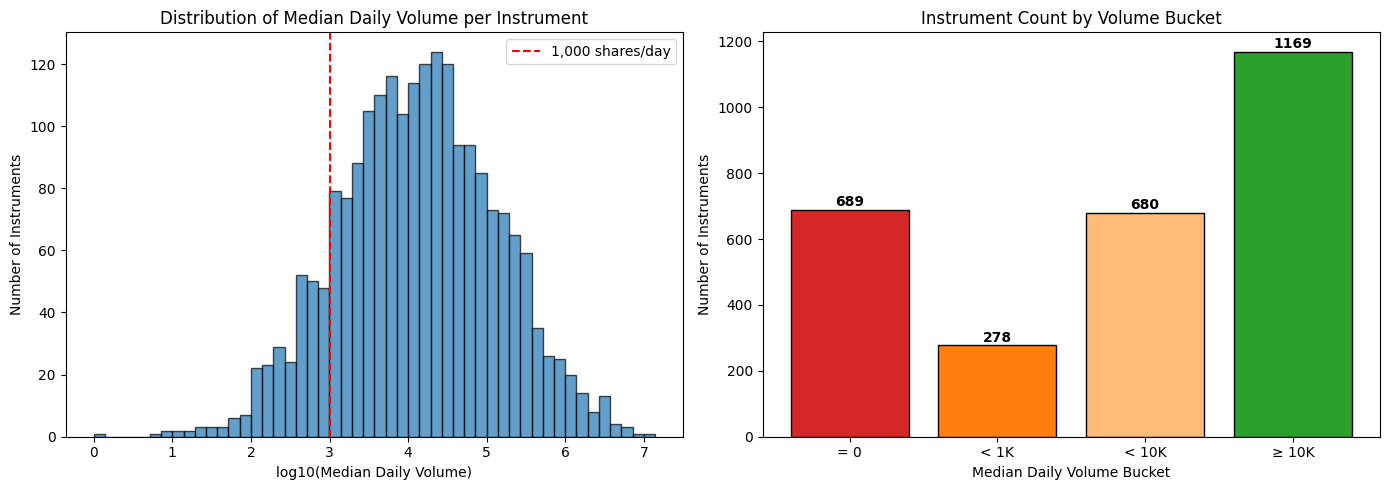


Summary:
  Zero median volume:    689 instruments
  < 1K median volume:    967 instruments
  < 10K median volume:  1647 instruments
  Total instruments:    2816


In [2]:
import duckdb
import matplotlib.pyplot as plt
import math

con = duckdb.connect()

# Median daily volume per instrument
vol_per_instr = con.sql("""
    SELECT
        insref,
        MEDIAN(volume) AS median_daily_volume,
        AVG(volume) AS avg_daily_volume,
        count(*) AS n_days
    FROM 'data/bars_1d.parquet'
    GROUP BY insref
    ORDER BY median_daily_volume
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of log10(median daily volume)
vol_nonzero = vol_per_instr[vol_per_instr["median_daily_volume"] > 0]["median_daily_volume"]
axes[0].hist(vol_nonzero.apply(math.log10), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("log10(Median Daily Volume)")
axes[0].set_ylabel("Number of Instruments")
axes[0].set_title("Distribution of Median Daily Volume per Instrument")
axes[0].axvline(x=3, color="red", linestyle="--", label="1,000 shares/day")
axes[0].legend()

# Bucket breakdown
zero_vol = int((vol_per_instr["median_daily_volume"] == 0).sum())
low_vol = int((vol_per_instr["median_daily_volume"] < 1000).sum())
med_vol = int((vol_per_instr["median_daily_volume"] < 10000).sum())
total = len(vol_per_instr)

labels = ["= 0", "< 1K", "< 10K", "≥ 10K"]
counts = [zero_vol, low_vol - zero_vol, med_vol - low_vol, total - med_vol]
colors = ["#d62728", "#ff7f0e", "#ffbb78", "#2ca02c"]
axes[1].bar(labels, counts, color=colors, edgecolor="black")
axes[1].set_xlabel("Median Daily Volume Bucket")
axes[1].set_ylabel("Number of Instruments")
axes[1].set_title("Instrument Count by Volume Bucket")
for i, c in enumerate(counts):
    axes[1].text(i, c + 10, str(c), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Zero median volume:  {zero_vol:>5} instruments")
print(f"  < 1K median volume:  {low_vol:>5} instruments")
print(f"  < 10K median volume: {med_vol:>5} instruments")
print(f"  Total instruments:   {total:>5}")

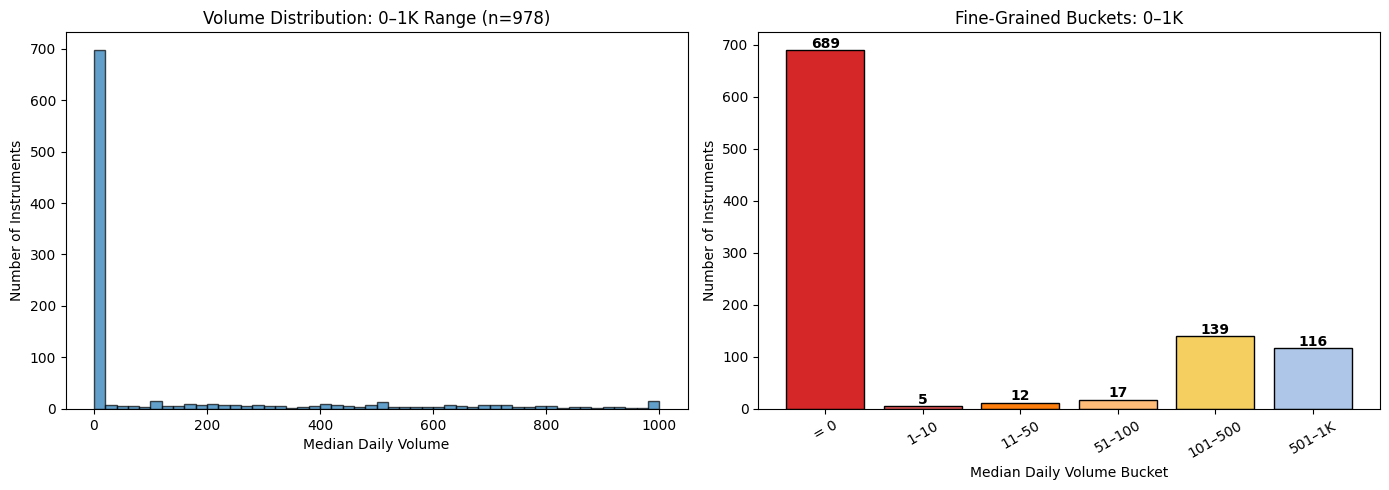


978 instruments with median daily volume ≤ 1,000
       = 0:   689 instruments
      1–10:     5 instruments
     11–50:    12 instruments
    51–100:    17 instruments
   101–500:   139 instruments
    501–1K:   116 instruments


In [3]:
# Drill-down: instruments with median daily volume 0 - 1,000
low_vol_df = vol_per_instr[vol_per_instr["median_daily_volume"] <= 1000].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of actual median volume values (0-1000 range)
axes[0].hist(low_vol_df["median_daily_volume"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Median Daily Volume")
axes[0].set_ylabel("Number of Instruments")
axes[0].set_title(f"Volume Distribution: 0–1K Range (n={len(low_vol_df)})")

# Right: finer buckets
buckets = [0, 0, 1, 10, 50, 100, 500, 1000]
bucket_labels = ["= 0", "1–10", "11–50", "51–100", "101–500", "501–1K"]
bucket_counts = [
    int((low_vol_df["median_daily_volume"] == 0).sum()),
    int(((low_vol_df["median_daily_volume"] > 0) & (low_vol_df["median_daily_volume"] <= 10)).sum()),
    int(((low_vol_df["median_daily_volume"] > 10) & (low_vol_df["median_daily_volume"] <= 50)).sum()),
    int(((low_vol_df["median_daily_volume"] > 50) & (low_vol_df["median_daily_volume"] <= 100)).sum()),
    int(((low_vol_df["median_daily_volume"] > 100) & (low_vol_df["median_daily_volume"] <= 500)).sum()),
    int(((low_vol_df["median_daily_volume"] > 500) & (low_vol_df["median_daily_volume"] <= 1000)).sum()),
]

colors = ["#d62728", "#e45756", "#ff7f0e", "#ffbb78", "#f5d060", "#aec7e8"]
axes[1].bar(bucket_labels, bucket_counts, color=colors, edgecolor="black")
axes[1].set_xlabel("Median Daily Volume Bucket")
axes[1].set_ylabel("Number of Instruments")
axes[1].set_title("Fine-Grained Buckets: 0–1K")
for i, c in enumerate(bucket_counts):
    axes[1].text(i, c + 5, str(c), ha="center", fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\n{len(low_vol_df)} instruments with median daily volume ≤ 1,000")
for lbl, cnt in zip(bucket_labels, bucket_counts):
    print(f"  {lbl:>8}: {cnt:>5} instruments")

In [4]:
# Did the 689 zero-median instruments ever trade at all?
zero_med_insrefs = vol_per_instr[vol_per_instr["median_daily_volume"] == 0]["insref"].tolist()
insref_list = ", ".join(str(x) for x in zero_med_insrefs)

zero_detail = con.sql(f"""
    SELECT
        insref,
        count(*) AS total_days,
        count(*) FILTER (volume > 0) AS days_with_volume,
        SUM(volume) AS lifetime_volume,
        MAX(volume) AS max_daily_volume,
        MIN(date) AS first_date,
        MAX(date) AS last_date
    FROM 'data/bars_1d.parquet'
    WHERE insref IN ({insref_list})
    GROUP BY insref
""").df()

never_traded = (zero_detail["days_with_volume"] == 0).sum()
sometimes_traded = (zero_detail["days_with_volume"] > 0).sum()

print(f"Of the 689 zero-median-volume instruments:")
print(f"  Never traded at all (0 days with volume): {never_traded}")
print(f"  Traded on some days (but median = 0):     {sometimes_traded}")
print()

# For those that did trade sometimes, how often?
sometimes = zero_detail[zero_detail["days_with_volume"] > 0].copy()
if len(sometimes) > 0:
    sometimes["pct_days_active"] = (sometimes["days_with_volume"] / sometimes["total_days"] * 100).round(1)
    print(f"Among the {len(sometimes)} that traded sometimes:")
    print(f"  Median % of days active: {sometimes['pct_days_active'].median():.1f}%")
    print(f"  Max % of days active:    {sometimes['pct_days_active'].max():.1f}%")
    print(f"  Median lifetime volume:  {sometimes['lifetime_volume'].median():,.0f}")
    print(f"  Max lifetime volume:     {sometimes['lifetime_volume'].max():,.0f}")
    print()
    print("Top 10 most active of the 'zero-median' group:")
    print(sometimes.nlargest(10, "days_with_volume")[
        ["insref", "total_days", "days_with_volume", "pct_days_active", "lifetime_volume", "max_daily_volume"]
    ].to_string(index=False))

Of the 689 zero-median-volume instruments:
  Never traded at all (0 days with volume): 689
  Traded on some days (but median = 0):     0



In [5]:
# Remove the 689 zero-volume instruments and save clean dataset
con.sql(f"""
    COPY (
        SELECT *
        FROM 'data/bars_1d.parquet'
        WHERE insref NOT IN ({insref_list})
        ORDER BY insref, date
    ) TO 'data/bars_1d_clean.parquet' (FORMAT PARQUET, COMPRESSION SNAPPY)
""")

# Verify
con.sql("""
    SELECT
        count(*) AS total_rows,
        count(DISTINCT insref) AS n_instruments,
        min(date) AS first_date,
        max(date) AS last_date,
        count(DISTINCT date) AS n_days
    FROM 'data/bars_1d_clean.parquet'
""").show()
print("Saved to data/bars_1d_clean.parquet")

┌────────────┬───────────────┬────────────┬────────────┬────────┐
│ total_rows │ n_instruments │ first_date │ last_date  │ n_days │
│   int64    │     int64     │    date    │    date    │ int64  │
├────────────┼───────────────┼────────────┼────────────┼────────┤
│    3422775 │          2127 │ 2015-01-02 │ 2026-03-23 │   2819 │
└────────────┴───────────────┴────────────┴────────────┴────────┘

Saved to data/bars_1d_clean.parquet
